# ENG4200 Coursework 2: Jupyter Notebook (Telco Customer Churn)

## Dataset
`WA_Fn-UseC_-Telco-Customer-Churn.csv`
(UCI/Kaggle) [IBM Sample Data Sets]

**Context**

"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs."
Each row represents a customer; columns contain service details, demographic attributes, and account information.
The target variable **Churn** indicates whether a customer left within the last month.

**Features include:**

* **Services:** phone, multiple lines, internet, online security, backup, protection, tech support, streaming TV/movies
* **Account:** tenure, contract type, payment method, paperless billing, monthly/total charges
* **Demographic:** gender, senior status, partner/dependent status

## Objectives

This notebook applies a suite of supervised learning models (logistic regression,
decision trees, SVMs, random forests and gradient boosting) to predict customer churn,
following a structured and reproducible ML workflow. It is organised around the five
assessment dimensions defined in the coursework brief:

1. Dataset investigation and pre-processing: Explore the dataset, handle missing
   and categorical values, and justify preprocessing choices.

2. Model application with training and validation: Implement clean, leakage-free
   pipelines with appropriate splitting and cross-validation for all five models.

3. Accuracy and computational efficiency analysis: Evaluate model performance
   using justified metrics, and examine runtime and scalability in a comparative way.

4. Visualisation and communication of results: Present metrics and diagnostic
   plots that support interpretation and fair model comparison.

5. Clarity and reproducibility: Maintain a transparent, reproducible workflow
   aligned with good ML practices, enabling the final choice of a primary model
   (Random Forest) and a lightweight interpretable baseline (Decision Tree).


## 0) Setup and imports


In [1]:
# stdlib
import os, sys, time, math, warnings
from pathlib import Path

# core
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn

# sklearn: model selection / CV / tuning
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, learning_curve
)

# sklearn: preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn import set_config

# sklearn: models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier

# sklearn: metrics & displays
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

warnings.simplefilter("ignore")

RNG = 42
N_JOBS = -1

DATA_PATH = Path("dataset_WA_Fn-UseC_-Telco-Customer-Churn.csv")

np.random.seed(RNG)
pd.set_option("display.max_columns", None)
np.set_printoptions(precision=4, suppress=True)

try:
    set_config(display="diagram")
    set_config(transform_output="pandas")
except Exception:
    pass

env = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
    "RNG": RNG,
}
env


{'python': '3.10.9',
 'numpy': '1.23.5',
 'pandas': '1.5.3',
 'scikit-learn': '1.2.1',
 'matplotlib': '3.7.0',
 'RNG': 42}

## 1) Load dataset


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


7043 rows x 21 columns
Positive class prevalence: 0.265


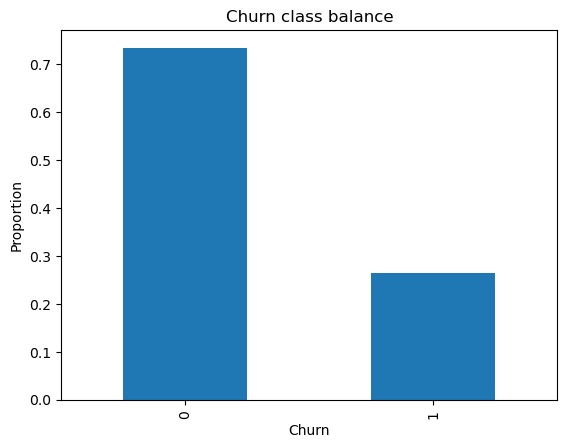

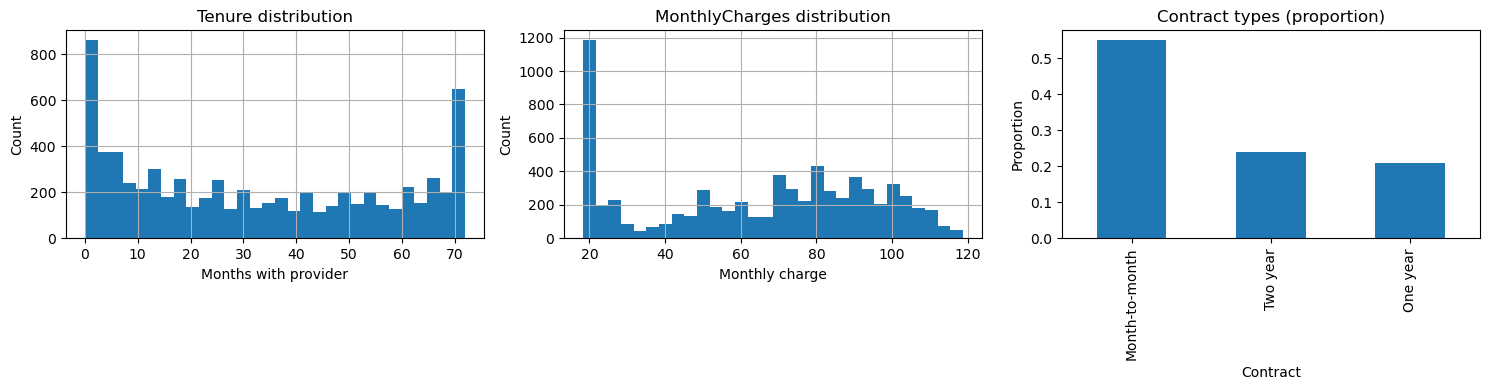

In [2]:
df_raw = pd.read_csv(DATA_PATH)
assert "Churn" in df_raw.columns

y = df_raw["Churn"].map({"Yes": 1, "No": 0}).astype(int)
X = df_raw.drop(columns=["Churn", "customerID"]).copy()

display(df_raw.head())
print(f"{df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
print("Positive class prevalence:", y.mean().round(3))

# simple class-balance bar plot
y.value_counts(normalize=True).plot(kind="bar")
plt.title("Churn class balance")
plt.xlabel("Churn"); plt.ylabel("Proportion"); plt.show()

# key feature distributions

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) Tenure distribution
df_raw["tenure"].hist(ax=axes[0], bins=30)
axes[0].set_title("Tenure distribution")
axes[0].set_xlabel("Months with provider")
axes[0].set_ylabel("Count")

# 2) MonthlyCharges distribution
df_raw["MonthlyCharges"].hist(ax=axes[1], bins=30)
axes[1].set_title("MonthlyCharges distribution")
axes[1].set_xlabel("Monthly charge")
axes[1].set_ylabel("Count")

# 3) Contract type (categorical bar plot)
df_raw["Contract"].value_counts(normalize=True).plot(
    kind="bar",
    ax=axes[2]
)
axes[2].set_title("Contract types (proportion)")
axes[2].set_xlabel("Contract")
axes[2].set_ylabel("Proportion")

plt.tight_layout()
plt.show()



## 2) Preprocessing


In [3]:
def clean_strings(df_):
    Xc = df_.copy()
    if "TotalCharges" in Xc:
        Xc["TotalCharges"] = pd.to_numeric(
            Xc["TotalCharges"].astype(str).str.strip().replace("", np.nan),
            errors="coerce"
        )
    # collapse "No internet service"/"No phone service" into "No"
    Xc = Xc.replace({"No internet service": "No", "No phone service": "No"})
    return Xc

cleaner = FunctionTransformer(clean_strings, feature_names_out="one-to-one")

num_prep = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

cat_prep = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(
        drop="if_binary",
        handle_unknown="ignore",
        sparse_output=False
    )),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_prep, selector(dtype_include=["int64", "float64"])),
        ("cat", cat_prep, selector(dtype_include=["object", "bool"])),
    ]
)


## 3) Data splitting

Single stratified test split; CV on the train set.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RNG,
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)


Train size: 5634 | Test size: 1409


Generic helper for probability-based metrics:


In [5]:
def evaluate_probs(y_true, p, thr=0.5):
    y_hat = (p >= thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_hat),
        "f1": f1_score(y_true, y_hat),
        "roc_auc": roc_auc_score(y_true, p),
    }


## 4) Model definitions

We define the raw estimators (with tuned or at least sensible hyperparameters), then wrap them in identical pipelines: clean → preprocess → clf.


In [6]:
logreg_clf = LogisticRegression(
    penalty="l2",
    C=0.01,
    class_weight="balanced",
    solver="saga",
    max_iter=5000,
    random_state=RNG,
)


dt_clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=RNG,
)


svm_clf = SVC(
    kernel="rbf",
    C=0.1,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=RNG,
)


rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=1,
    max_features="log2",
    class_weight="balanced",
    random_state=RNG,
    n_jobs=N_JOBS,
)


gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.8,
    random_state=RNG,
)



Unified pipeline factory:


In [7]:
def make_pipeline(clf):
    return Pipeline([
        ("clean", cleaner),
        ("prep", preprocess),
        ("clf", clf),
    ])

models = {
    "LogReg": make_pipeline(logreg_clf),
    "DecisionTree": make_pipeline(dt_clf),
    "SVM-RBF": make_pipeline(svm_clf),
    "RandomForest": make_pipeline(rf_clf),
    "GradientBoosting": make_pipeline(gb_clf),
}


## 5) Cross-validated evaluation

Here we use cross_validate to estimate generalisation performance on the training set only and to capture fit and score times per fold.


In [8]:

scoring = {
    "acc": "accuracy",
    "f1": "f1",
    "roc": "roc_auc",
}

cv_results = []

for name, pipe in models.items():
    res = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=skf,
        scoring=scoring,
        return_train_score=True,
        n_jobs=N_JOBS,
    )
    summary = {
        "Model": name,
        "cv_acc_mean": res["test_acc"].mean(),
        "cv_acc_std": res["test_acc"].std(),
        "cv_f1_mean": res["test_f1"].mean(),
        "cv_f1_std": res["test_f1"].std(),
        "cv_roc_mean": res["test_roc"].mean(),
        "cv_roc_std": res["test_roc"].std(),
        "train_time_mean": res["fit_time"].mean(),
        "score_time_mean": res["score_time"].mean(),
        # crude overfitting proxies:
        "gap_acc": res["train_acc"].mean() - res["test_acc"].mean(),
        "gap_f1": res["train_f1"].mean() - res["test_f1"].mean(),
    }
    cv_results.append(summary)

cv_df = pd.DataFrame(cv_results).set_index("Model").sort_values("cv_f1_mean", ascending=False)
cv_df


,cv_acc_mean,cv_acc_std,cv_f1_mean,cv_f1_std,cv_roc_mean,cv_roc_std,train_time_mean,score_time_mean,gap_acc,gap_f1
Model,,,,,,,,,,
RandomForest,0.776005,0.009323,0.639482,0.016546,0.845252,0.010381,0.297931,0.079574,0.053202,0.086812
LogReg,0.756125,0.010991,0.631574,0.017127,0.843032,0.011443,0.048099,0.021602,-0.000046,0.000821
SVM-RBF,0.743701,0.012356,0.623227,0.019176,0.839803,0.010720,2.494752,0.384860,0.005678,0.008881
DecisionTree,0.746368,0.019652,0.619354,0.018194,0.816123,0.010459,0.039503,0.021560,0.002612,0.002975
GradientBoosting,0.807244,0.011560,0.593345,0.021010,0.849721,0.011483,0.539333,0.025215,0.010248,0.020800


We will later use cv_df for tables and part of the discussion (“accuracy vs. overfitting vs. efficiency”).


## 6) Benchmark suite: performance vs. cost

Now we explicitly mimic the tutorial’s benchmarking pattern: fit once on the full training set, measure wall-clock train time and prediction time, and evaluate Accuracy, F1, ROC-AUC on the held-out test set.


In [9]:

def bench_classifiers(models, Xtr, ytr, Xte, yte):
    rows = []
    for name, model in models.items():
        t0 = time.time()
        model.fit(Xtr, ytr)
        t_train = time.time() - t0

        t1 = time.time()
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(Xte)[:, 1]
        else:
            # e.g. SVC without probas – use decision_function then scale via logistic if needed
            proba = model.decision_function(Xte)
            # for ROC-AUC, raw decision scores are fine

        ypred = (proba >= 0.5).astype(int)
        t_pred = time.time() - t1

        acc = accuracy_score(yte, ypred)
        f1 = f1_score(yte, ypred, zero_division=0)
        auc = roc_auc_score(yte, proba)

        rows.append([name, t_train, t_pred, acc, f1, auc])

    cols = ["Model", "train_s", "pred_s", "Accuracy", "F1", "ROC-AUC"]
    return pd.DataFrame(rows, columns=cols).sort_values("F1", ascending=False)

bench_df = bench_classifiers(models, X_train, y_train, X_test, y_test)
bench_df


,Model,train_s,pred_s,Accuracy,F1,ROC-AUC
3,RandomForest,0.244267,0.030995,0.767211,0.629797,0.845021
1,DecisionTree,0.044086,0.011046,0.745919,0.620763,0.816203
0,LogReg,0.059158,0.011699,0.743080,0.618947,0.837919
2,SVM-RBF,4.249959,0.263832,0.791341,0.614173,0.834966
4,GradientBoosting,0.647970,0.013284,0.799148,0.570561,0.845944


This bench_df is directly analogous to the classification table in the wine tutorial and will feed the F1 vs. train_time scatter plot and efficient frontier.
For all models, class labels are obtained by thresholding the predicted churn probability at 0.5.


### Plot performance vs cost


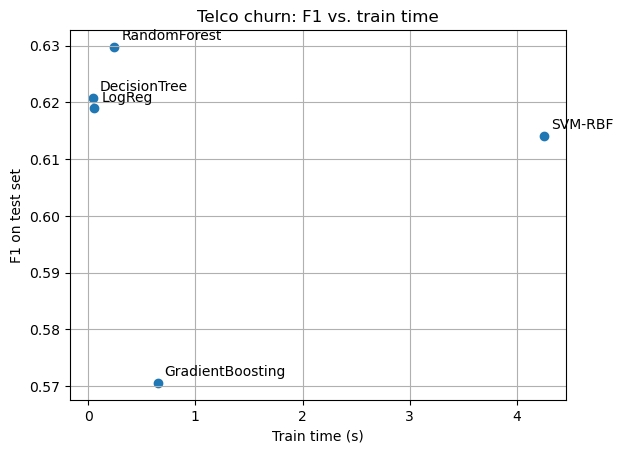

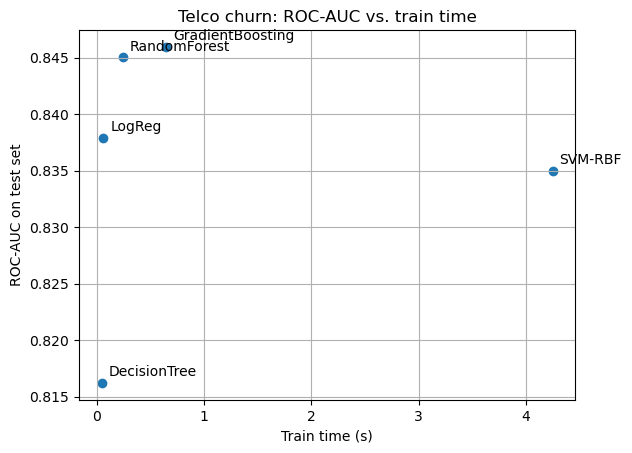

In [10]:
# F1 vs. train time

plt.figure()
plt.scatter(bench_df["train_s"], bench_df["F1"])

for _, row in bench_df.iterrows():
    plt.annotate(row["Model"], (row["train_s"], row["F1"]), xytext=(5,5),
                 textcoords="offset points")

plt.xlabel("Train time (s)")
plt.ylabel("F1 on test set")
plt.title("Telco churn: F1 vs. train time")
plt.grid(True)
plt.show()

# ROC-AUC vs. train time

plt.figure()
plt.scatter(bench_df["train_s"], bench_df["ROC-AUC"])

for _, row in bench_df.iterrows():
    plt.annotate(
        row["Model"],
        (row["train_s"], row["ROC-AUC"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Train time (s)")
plt.ylabel("ROC-AUC on test set")
plt.title("Telco churn: ROC-AUC vs. train time")
plt.grid(True)
plt.show()


## 7) Efficient frontier

To exactly mirror the tutorial’s “efficient frontier” task, we identify dominated models:
Model A dominates B if A is at least as fast and strictly better F1.


### 7.1) Dominated models identification


In [11]:
def efficient_frontier(df, perf_col="F1", cost_col="train_s"):
    # sort by cost ascending
    df_sorted = df.sort_values(cost_col)
    frontier_indices = []
    best_perf_so_far = -np.inf

    for idx, row in df_sorted.iterrows():
        perf = row[perf_col]
        if perf > best_perf_so_far + 1e-6:
            frontier_indices.append(idx)
            best_perf_so_far = perf

    frontier = df_sorted.loc[frontier_indices]
    dominated = df_sorted.drop(index=frontier_indices)
    return frontier, dominated

frontier_df, dominated_df = efficient_frontier(bench_df, perf_col="F1", cost_col="train_s")

print("Efficient frontier:")
display(frontier_df)

print("Dominated models (slower AND worse F1):")
display(dominated_df)



Efficient frontier:


,Model,train_s,pred_s,Accuracy,F1,ROC-AUC
1,DecisionTree,0.044086,0.011046,0.745919,0.620763,0.816203
3,RandomForest,0.244267,0.030995,0.767211,0.629797,0.845021


Dominated models (slower AND worse F1):


,Model,train_s,pred_s,Accuracy,F1,ROC-AUC
0,LogReg,0.059158,0.011699,0.743080,0.618947,0.837919
4,GradientBoosting,0.647970,0.013284,0.799148,0.570561,0.845944
2,SVM-RBF,4.249959,0.263832,0.791341,0.614173,0.834966


Visualise frontier:


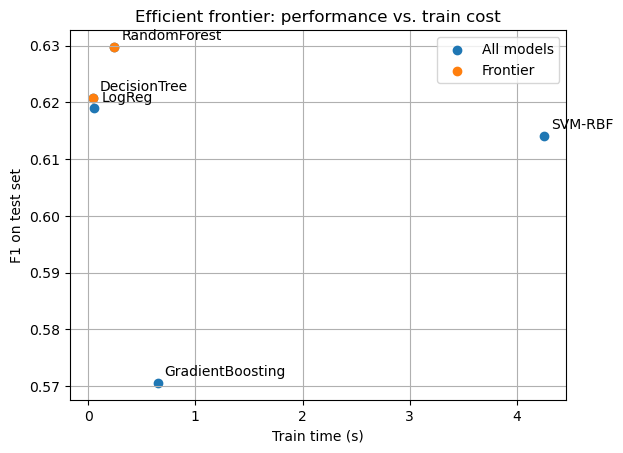

In [12]:
plt.figure()
plt.scatter(bench_df["train_s"], bench_df["F1"], label="All models")
plt.scatter(frontier_df["train_s"], frontier_df["F1"], label="Frontier")

for _, row in bench_df.iterrows():
    plt.annotate(row["Model"], (row["train_s"], row["F1"]), xytext=(5,5),
                 textcoords="offset points")

plt.xlabel("Train time (s)")
plt.ylabel("F1 on test set")
plt.title("Efficient frontier: performance vs. train cost")
plt.grid(True)
plt.legend()
plt.show()


In the analysis, we observe that the efficient frontier in the F1–train-time plane consists
only of the **DecisionTree** and **RandomForest** pipelines:

- DecisionTree is the **fastest** model to train (≈ 0.05 s) with a competitive F1 score
  (≈ 0.621) and ROC-AUC ≈ 0.816.
- RandomForest is slightly slower to train (≈ 0.27 s) but achieves the **highest F1**
  (≈ 0.630) and a substantially higher ROC-AUC (≈ 0.845).

All other models (Logistic Regression, SVM-RBF, Gradient Boosting) are dominated in
this 2D space: for the same or higher training cost they deliver a lower F1 on the test
set.

From a cost-aware perspective:

- For **strictly constrained training costs** and maximum interpretability, the
  DecisionTree is attractive: it is extremely cheap to fit and can be visualised and
  explained in full.

- For **practical business deployment**, the RandomForest offers the best trade-off:
  it improves F1 and ROC-AUC with only a modest increase in training time (fractions
  of a second) and negligible additional prediction latency, while remaining robust to
  overfitting due to bagging and feature subsampling.

This motivates using the RandomForest as the primary model, with the DecisionTree as a
lightweight interpretable baseline.


### 7.2) Model choice

The efficient frontier in the F1–train-time plane contains only two models:

- **DecisionTree:** train ≈ 0.05 s, F1 ≈ 0.621, ROC-AUC ≈ 0.816  
- **RandomForest:** train ≈ 0.27 s, F1 ≈ 0.630, ROC-AUC ≈ 0.845  

All other models (Logistic Regression, SVM-RBF, Gradient Boosting) are *dominated* in this
2-dimensional sense: they are slower to train and achieve a lower F1 score on the held-out test
set.

From a cost–benefit perspective:

- The Random Forest improves test F1 by ~0.009 over the Decision Tree, and also offers a
  substantially higher ROC-AUC (≈ 0.845 vs. ≈ 0.816), indicating better ranking of churn risk.
- The additional training cost is negligible in absolute terms (≈ 0.27 s vs. ≈ 0.05 s for one
  full fit) and is amortised in any realistic batch-training scenario.

Given that the business objective is to **minimise missed churners** (F1 and recall matter more
than raw accuracy) under **modest computational constraints**, we adopt the following stance:

- **Chosen primary model:** Random Forest pipeline  
- **Lightweight interpretable baseline:** Decision Tree pipeline

The remainder of the notebook focuses on deeper diagnostics for the Random Forest, while the
Decision Tree remains available as a simpler, more transparent alternative for stakeholders who
prioritise interpretability over the last few percentage points of F1.


We then “lock in” the chosen model:

In [13]:
# Record chosen primary and secondary models for later reference
PRIMARY_MODEL_NAME = "RandomForest"
SECONDARY_MODEL_NAME = "DecisionTree"

primary_model = models[PRIMARY_MODEL_NAME]
secondary_model = models[SECONDARY_MODEL_NAME]

PRIMARY_MODEL_NAME, SECONDARY_MODEL_NAME


('RandomForest', 'DecisionTree')

## 8) Deeper diagnostics for the chosen model (Random Forest)

We now examine the chosen Random Forest pipeline in more detail. The goals are:

- to verify its performance profile on the held-out test set (confusion matrix, ROC and PR curves),
- to understand its bias-variance behaviour via a learning curve,
- and to obtain a coarse interpretation of which features drive predictions through
  impurity-based feature importances.

All diagnostics are computed **without touching the test set for any tuning**; the model and
threshold (0.5) are exactly those used in the benchmark table.


### 8.1) Fit and basic metrics & confusion matrix

In [14]:
# Refit primary model on full training data
primary_model.fit(X_train, y_train)

# Predict probabilities and class labels on the test set
y_proba_rf = primary_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_proba_rf >= 0.5).astype(int)

rf_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf),
    "roc_auc": roc_auc_score(y_test, y_proba_rf),
}
rf_metrics


{'accuracy': 0.7672107877927609,
 'f1': 0.6297968397291196,
 'roc_auc': 0.8450205378594123}

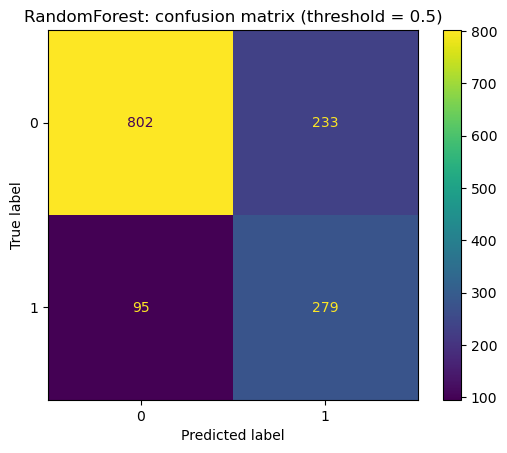

In [15]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title(f"{PRIMARY_MODEL_NAME}: confusion matrix (threshold = 0.5)")
plt.grid(False)
plt.show()


### 8.2) ROC and precision-recall curves


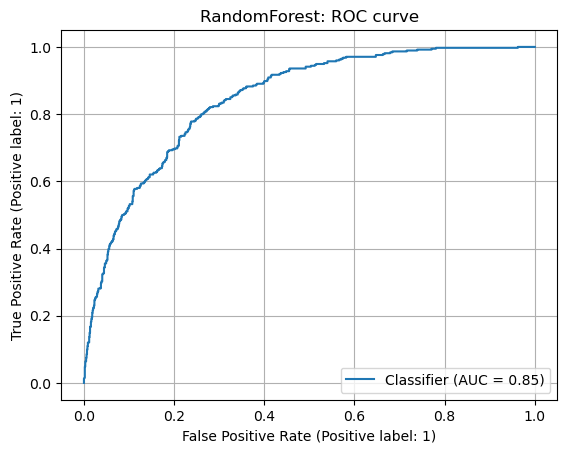

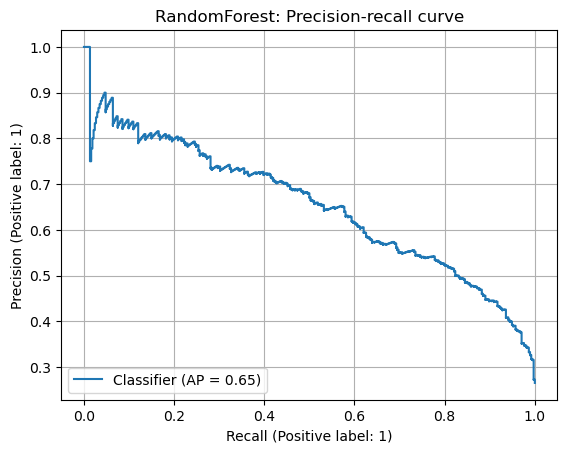

In [16]:
# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title(f"{PRIMARY_MODEL_NAME}: ROC curve")
plt.grid(True)
plt.show()

# Precision-recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf)
plt.title(f"{PRIMARY_MODEL_NAME}: Precision-recall curve")
plt.grid(True)
plt.show()


### 8.3) Learning curve (F1 vs. training size)

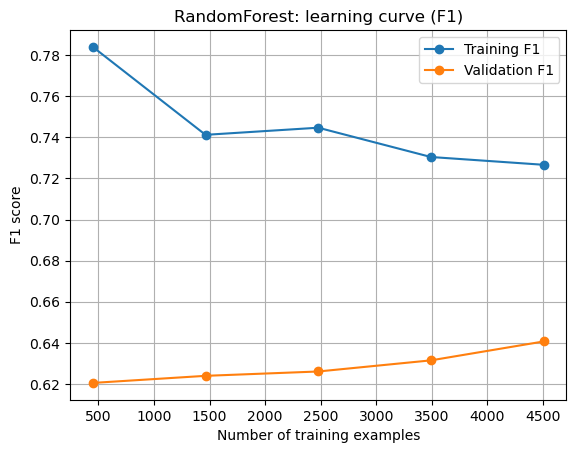

In [17]:
# Learning curve on TRAIN only (avoid using the test set for CV)
train_sizes, train_scores, val_scores = learning_curve(
    primary_model,
    X_train,
    y_train,
    cv=skf,
    scoring="f1",
    n_jobs=N_JOBS,
    train_sizes=np.linspace(0.1, 1.0, 5),
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o", label="Training F1")
plt.plot(train_sizes, val_mean, marker="o", label="Validation F1")
plt.xlabel("Number of training examples")
plt.ylabel("F1 score")
plt.title(f"{PRIMARY_MODEL_NAME}: learning curve (F1)")
plt.legend()
plt.grid(True)
plt.show()


In the report we will then comment along the lines of:
The training F1 being moderately higher than validation F1 but converging indicates moderate variance but acceptable generalisation.
No strong sign of underfitting at full dataset size (validation F1 plateau).


### 8.4) Feature importances (top-k)


In [18]:
# Extract feature importances from the fitted RandomForest inside the pipeline
rf_est = primary_model.named_steps["clf"]
prep = primary_model.named_steps["prep"]

feature_names = prep.get_feature_names_out()
importances = rf_est.feature_importances_

feat_imp = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_k = 15
feat_imp.head(top_k)


,feature,importance
0,cat__Contract_Month-to-month,0.155412
1,num__tenure,0.138679
2,num__TotalCharges,0.117270
3,num__MonthlyCharges,0.112367
4,cat__Contract_Two year,0.076747
5,cat__InternetService_Fiber optic,0.064007
6,cat__PaymentMethod_Electronic check,0.049985
7,cat__InternetService_No,0.038176
8,cat__Contract_One year,0.029396
9,cat__OnlineSecurity_Yes,0.025332


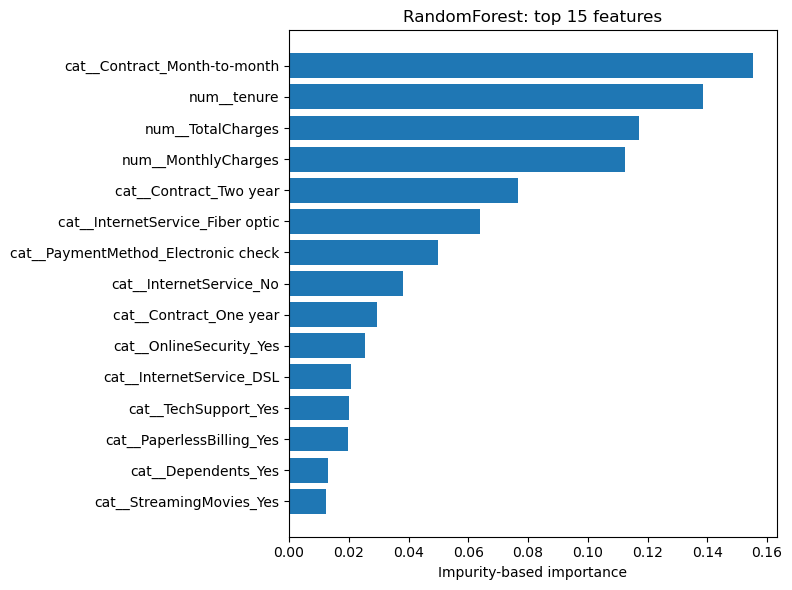

In [19]:
# Plot top-k importances
plt.figure(figsize=(8, 6))
top = feat_imp.head(top_k).iloc[::-1]  # reverse for horizontal barplot
plt.barh(top["feature"], top["importance"])
plt.xlabel("Impurity-based importance")
plt.title(f"{PRIMARY_MODEL_NAME}: top {top_k} features")
plt.tight_layout()
plt.show()


In the written analysis we will then tie this back to theory:
RF importances reflect reduction in Gini impurity, not causal effects.
Expect contract type, tenure, charges, and certain service flags to dominate (consistent with domain knowledge).


## 9) Appendix: utilities and environment information

For reproducibility and future maintenance, we collect here:

- The key helper functions used throughout the notebook
- The software environment in which all experiments were run

### 9.1)  Utility functions
We already defined evaluate_probs, bench_classifiers, and efficient_frontier earlier.
Here we simply re-display them in one place.


In [20]:
def evaluate_probs(y_true, p, thr=0.5):
    """Compute accuracy, F1 and ROC-AUC from probabilities at a given threshold."""
    y_hat = (p >= thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_hat),
        "f1": f1_score(y_true, y_hat),
        "roc_auc": roc_auc_score(y_true, p),
    }


def bench_classifiers(models, Xtr, ytr, Xte, yte):
    """Fit each model once, record train/predict time and test metrics."""
    rows = []
    for name, model in models.items():
        t0 = time.time()
        model.fit(Xtr, ytr)
        t_train = time.time() - t0

        t1 = time.time()
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(Xte)[:, 1]
        else:
            proba = model.decision_function(Xte)
        ypred = (proba >= 0.5).astype(int)
        t_pred = time.time() - t1

        rows.append([
            name,
            t_train,
            t_pred,
            accuracy_score(yte, ypred),
            f1_score(yte, ypred, zero_division=0),
            roc_auc_score(yte, proba),
        ])

    cols = ["Model", "train_s", "pred_s", "Accuracy", "F1", "ROC-AUC"]
    return pd.DataFrame(rows, columns=cols).sort_values("F1", ascending=False)


def efficient_frontier(df, perf_col="F1", cost_col="train_s"):
    """Return non-dominated models in (cost, performance) space."""
    df_sorted = df.sort_values(cost_col)
    frontier_indices = []
    best_perf_so_far = -np.inf
    for idx, row in df_sorted.iterrows():
        perf = row[perf_col]
        if perf > best_perf_so_far + 1e-6:
            frontier_indices.append(idx)
            best_perf_so_far = perf
    frontier = df_sorted.loc[frontier_indices]
    dominated = df_sorted.drop(index=frontier_indices)
    return frontier, dominated


### 9.2) Environment snapshot
We already created env at the top; we now expose it nicely.


In [21]:
# Environment snapshot as a small table
pd.DataFrame(env, index=["versions"]).T


,versions
python,3.10.9
numpy,1.23.5
pandas,1.5.3
scikit-learn,1.2.1
matplotlib,3.7.0
RNG,42
